# MuJoCo Kinematics: Forward and Inverse Kinematics of an RR Arm

## Learning Objectives

- Understand what forward kinematics (FK) and inverse kinematics (IK) are
- Derive and implement the analytic FK equations for a planar 2-link (RR) arm
- Use MuJoCo to compute FK numerically and compare against the analytic solution
- Read and interpret MuJoCo Jacobians (`mj_jacSite`)
- Derive the Jacobian analytically and connect it to FK derivatives
- Solve IK in closed form and understand the two elbow configurations
- Implement numerical IK with damped least squares (Newton-style iteration)
- Detect and avoid kinematic singularities

## The Robot

We use the planar RR arm bundled with `dms` (`planar_rr_arm.xml`):
two revolute joints rotating about the **Y axis**, so the arm moves in the
vertical **X-Z plane**.

- Shoulder at height $z_0 = 1.0$ m (origin of the arm)
- Link 1: $L_1 = 0.4$ m
- Link 2: $L_2 = 0.3$ m
- End-effector site `ee` at the tip of link 2

Positive joint angles rotate the arm **downward** (rotation about +Y:
$x$ goes like $\cos q$, $z$ decreases like $-\sin q$).

## Setup

In [1]:
import numpy as np
import mujoco
import matplotlib.pyplot as plt
import mediapy as media
import dms

model_path = dms.get_asset_path("mujoco_models/planar_rr_arm.xml")
model = mujoco.MjModel.from_xml_path(model_path)
data = mujoco.MjData(model)

# Useful model quantities
L1 = 0.4  # link 1 length (m) -- matches the XML capsule fromto
L2 = 0.3  # link 2 length (m)
Z0 = 1.0  # shoulder height (m)
ee_id = model.site("ee").id
print(f"nq={model.nq}, nv={model.nv}, ee site id={ee_id}")

nq=2, nv=2, ee site id=0


## Section 1: Forward Kinematics -- the Math

**Forward kinematics (FK)** answers: *given the joint angles, where is the
end-effector?* It is a simple, always-well-defined mapping
$q \mapsto x$.

For a planar 2R arm with joints rotating about +Y, the elbow position and
end-effector position are:

$$
\begin{aligned}
x_e &= L_1 \cos q_1, & z_e &= z_0 - L_1 \sin q_1 \\
x   &= L_1 \cos q_1 + L_2 \cos(q_1 + q_2), & z &= z_0 - L_1 \sin q_1 - L_2 \sin(q_1 + q_2)
\end{aligned}
$$

where $q_1$ is the shoulder angle and $q_2$ the elbow angle (both measured
relative to the previous link).

In [2]:
def fk_analytic(q1, q2):
    """Analytic end-effector position (x, z) for the planar RR arm."""
    x = L1 * np.cos(q1) + L2 * np.cos(q1 + q2)
    z = Z0 - (L1 * np.sin(q1) + L2 * np.sin(q1 + q2))
    return np.array([x, z])

def fk_analytic_full(q1, q2):
    """Analytic FK returning (elbow, end-effector) positions."""
    elbow = np.array([L1 * np.cos(q1), Z0 - L1 * np.sin(q1)])
    ee = fk_analytic(q1, q2)
    return elbow, ee

print(fk_analytic(0.0, 0.0))    # stretched out along +x: (0.7, 1.0)
print(fk_analytic(np.pi/2, 0.0))  # link1 down, link2 horizontal: (0.0, 0.6)

def fk_analytic3(q1, q2):
    """Analytic end-effector position as (x, 0, z), matching MuJoCo's 3D site_xpos."""
    x, z = fk_analytic(q1, q2)
    return np.array([x, 0.0, z])


[0.7 1. ]
[4.2862638e-17 3.0000000e-01]


## Section 2: Forward Kinematics in MuJoCo

In MuJoCo you never write the FK equations yourself: after setting
`data.qpos` you call **`mujoco.mj_forward(model, data)`**, which recomputes
all derived quantities, including body and site positions:

- `data.site_xpos[site_id]` -- world position of a site (our end-effector)
- `data.xpos[body_id]` -- world position of a body frame origin
- `data.xmat[body_id]` -- body orientation as a 3x3 rotation matrix

`mj_forward` computes much more than kinematics (it runs the whole pipeline:
positions, velocities, and forces); the pure-kinematics call is
`mj_kinematics`, but `mj_forward` is the standard convenience.

In [3]:
def fk_mujoco(q1, q2):
    """End-effector (x, y, z) from MuJoCo for joint angles (q1, q2)."""
    mujoco.mj_resetData(model, data)   # clear qpos/qvel and all derived data
    data.qpos[:] = [q1, q2]
    mujoco.mj_forward(model, data)
    return data.site_xpos[ee_id].copy()

# Compare MuJoCo against our analytic solution on a grid of poses
print(f"{'q1 (deg)':>9} {'q2 (deg)':>9} | {'MuJoCo (x, z)':>24} | {'analytic (x, z)':>24}")
rng = np.random.default_rng(0)
for q1, q2 in rng.uniform(-np.pi, np.pi, size=(5, 2)):
    pm = fk_mujoco(q1, q2)
    pa = fk_analytic3(q1, q2)
    print(f"{np.degrees(q1):9.1f} {np.degrees(q2):9.1f} | "
          f"({pm[0]:+8.4f}, {pm[2]:+8.4f})   | ({pa[0]:+8.4f}, {pa[2]:+8.4f})")

 q1 (deg)  q2 (deg) |            MuJoCo (x, z) |          analytic (x, z)
     49.3     -82.9 | ( +0.5108,  +0.8626)   | ( +0.5108,  +0.8626)
   -165.2    -174.1 | ( -0.1062,  +0.9958)   | ( -0.1062,  +0.9958)
    112.8     148.6 | ( -0.1999,  +0.9278)   | ( -0.1999,  +0.9278)
     38.4      82.6 | ( +0.1590,  +0.4945)   | ( +0.1590,  +0.4945)
     15.7     156.6 | ( +0.0878,  +0.8517)   | ( +0.0878,  +0.8517)


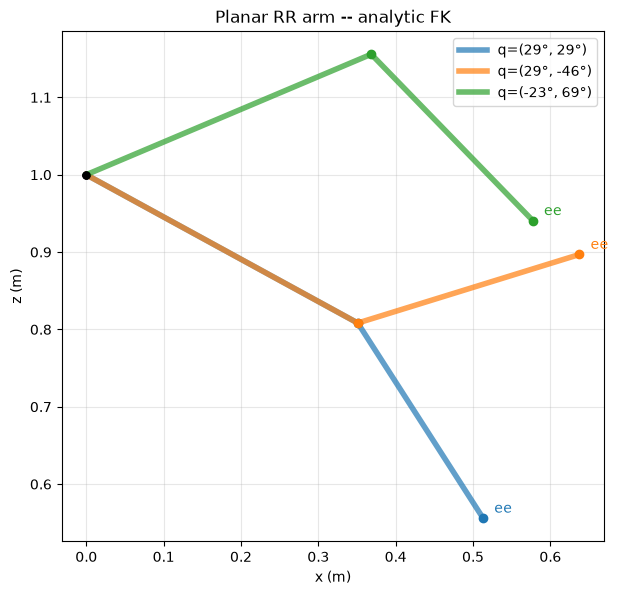

In [4]:
# Visualize the arm pose from the FK quantities
def plot_arm(ax, q1, q2, color='C0', label=None):
    elbow, ee = fk_analytic_full(q1, q2)
    ax.plot([0, elbow[0]], [Z0, elbow[1]], '-', color=color, linewidth=4,
            alpha=0.7, label=label)
    ax.plot([elbow[0], ee[0]], [elbow[1], ee[1]], '-', color=color, linewidth=4,
            alpha=0.7)
    ax.plot([elbow[0], ee[0]], [elbow[1], ee[1]], '.', color=color, markersize=12)
    ax.plot(0, Z0, 'k.', markersize=10)
    ax.annotate('ee', ee, textcoords='offset points', xytext=(8, 4), color=color)
    return ax

fig, ax = plt.subplots(figsize=(7, 7))
for q1, q2, c in [(0.5, 0.5, 'C0'), (0.5, -0.8, 'C1'), (-0.4, 1.2, 'C2')]:
    plot_arm(ax, q1, q2, color=c, label=f"q=({np.degrees(q1):.0f}°, {np.degrees(q2):.0f}°)")
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_xlabel('x (m)'); ax.set_ylabel('z (m)')
ax.legend(); ax.set_title('Planar RR arm -- analytic FK'); plt.show()

## Section 3: Seeing the Pose in the Renderer

Let's render one of the FK poses to confirm the geometry matches our
sketch. Note that the analytic FK and MuJoCo agree exactly, including the
1 m shoulder height.

MuJoCo ee:   [0.402  0.     0.5126]
analytic ee: [0.402  0.     0.5126]


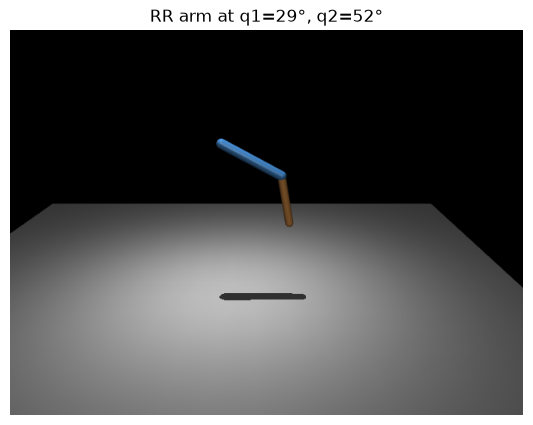

In [5]:
renderer = mujoco.Renderer(model, height=480, width=640)

q1, q2 = 0.5, 0.9
mujoco.mj_resetData(model, data)
data.qpos[:] = [q1, q2]
mujoco.mj_forward(model, data)
print(f"MuJoCo ee:   {np.round(data.site_xpos[ee_id], 4)}")
print(f"analytic ee: {np.round(fk_analytic3(q1, q2), 4)}")

renderer.update_scene(data, dms.mujoco.make_camera(model))
frame = renderer.render()
plt.figure(figsize=(8, 5))
plt.imshow(frame)
plt.axis('off')
plt.title(f'RR arm at q1={np.degrees(q1):.0f}°, q2={np.degrees(q2):.0f}°')
plt.show()

## Section 4: The Jacobian

The **Jacobian** $J(q)$ maps joint velocities to end-effector velocities:

$$v = J(q)\,\dot{q}$$

For our planar arm, differentiating the FK equations gives a $2 \times 2$
matrix (we keep the $(x, z)$ rows):

$$
J(q) = \begin{bmatrix}
\dfrac{\partial x}{\partial q_1} & \dfrac{\partial x}{\partial q_2} \\[6pt]
\dfrac{\partial z}{\partial q_1} & \dfrac{\partial z}{\partial q_2}
\end{bmatrix}
= \begin{bmatrix}
-(L_1 \sin q_1 + L_2 \sin(q_1{+}q_2)) & -L_2 \sin(q_1{+}q_2) \\[6pt]
-(L_1 \cos q_1 + L_2 \cos(q_1{+}q_2)) & -L_2 \cos(q_1{+}q_2)
\end{bmatrix}
$$

MuJoCo computes Jacobians for you with **`mj_jacSite`** (or `mj_jac`,
`mj_jacBody`), which return full $3 \times nv$ linear and angular
Jacobians in world coordinates.

In [6]:
def jac_analytic(q1, q2):
    """Analytic 2x2 planar Jacobian mapping [dq1, dq2] -> [dx, dz]."""
    s1, c1 = np.sin(q1), np.cos(q1)
    s12, c12 = np.sin(q1 + q2), np.cos(q1 + q2)
    return np.array([
        [-L1 * s1 - L2 * s12, -L2 * s12],
        [-L1 * c1 - L2 * c12, -L2 * c12],
    ])

def jac_mujoco():
    """MuJoCo site Jacobian rows for x and z (3 x nv)."""
    jacp = np.zeros((3, model.nv))
    jacr = np.zeros((3, model.nv))
    mujoco.mj_jacSite(model, data, jacp, jacr, ee_id)
    return jacp[[0, 2], :]  # keep x and z rows

# Compare at a random pose (mj_jacSite uses the *current* data state)
mujoco.mj_resetData(model, data)
q1, q2 = 0.3, -0.5
data.qpos[:] = [q1, q2]
mujoco.mj_forward(model, data)
print("MuJoCo J (x,z rows):");  print(np.round(jac_mujoco(), 4))
print("analytic J:");          print(np.round(jac_analytic(q1, q2), 4))

MuJoCo J (x,z rows):
[[-0.0586  0.0596]
 [-0.6762 -0.294 ]]
analytic J:
[[-0.0586  0.0596]
 [-0.6762 -0.294 ]]


In [7]:
# Verify the Jacobian numerically with finite differences: J columns are
# the derivatives of FK with respect to each joint angle.
q1, q2 = 0.3, -0.5
mujoco.mj_resetData(model, data)
data.qpos[:] = [q1, q2]
mujoco.mj_forward(model, data)

eps = 1e-6
J_num = np.zeros((2, 2))
for j in range(2):
    qp = np.array([q1, q2], float); qp[j] += eps
    qm = np.array([q1, q2], float); qm[j] -= eps
    J_num[:, j] = (fk_analytic(*qp) - fk_analytic(*qm)) / (2 * eps)

print("finite-difference J:"); print(np.round(J_num, 6))
print("max |J_num - J_analytic| =", np.abs(J_num - jac_analytic(q1, q2)).max())

finite-difference J:
[[-0.058607  0.059601]
 [-0.676155 -0.29402 ]]
max |J_num - J_analytic| = 1.5714596290905547e-11


In [8]:
# The Jacobian in action: joint velocity -> Cartesian velocity
q1, q2 = 0.5, 0.4
dq = np.array([0.5, -1.0])           # joint rates (rad/s)
v = jac_analytic(q1, q2) @ dq
print(f"joint rates    : {dq} rad/s")
print(f"ee velocity    : ({v[0]:+.4f}, {v[1]:+.4f}) m/s")
print(f"|v|            : {np.linalg.norm(v):.4f} m/s")

# Sanity check by integrating over a short interval
dt = 1e-4
p0 = fk_analytic(q1, q2)
p1 = fk_analytic(q1 + dq[0] * dt, q2 + dq[1] * dt)
print(f"finite-diff vel: {(p1 - p0) / dt} m/s")

joint rates    : [ 0.5 -1. ] rad/s
ee velocity    : (+0.0216, -0.0823) m/s
|v|            : 0.0851 m/s
finite-diff vel: [ 0.02160721 -0.08226968] m/s


## Section 5: Singularities

The arm loses a degree of freedom wherever $\det J = 0$. For the planar RR
arm this happens when the arm is fully stretched or fully folded:

$$\det J = L_1 L_2 \sin q_2$$

- **$q_2 = 0$** (fully stretched): the hand can only move perpendicular to
  the arm; radial motion is impossible.
- **$q_2 = \pm\pi$** (fully folded): the two links overlap.

Near singularities, achieving a desired Cartesian velocity requires huge
joint velocities -- this is why IK must handle these configurations
carefully.

In [9]:
q1, q2 = 0.3, 0.0
print(f"det J at q2=0 (stretched): {np.linalg.det(jac_analytic(q1, q2)):.2e}")
q1, q2 = 0.3, np.pi
print(f"det J at q2=pi (folded)  : {np.linalg.det(jac_analytic(q1, q2)):.2e}")

# Near-singular behavior: a purely radial target velocity requires
# enormous joint rates as q2 -> 0.
v_des = np.array([1.0, 0.0])   # want to move along +x at 1 m/s
for q2 in [0.5, 0.1, 0.01]:
    q1 = 0.3
    J = jac_analytic(q1, q2)
    dq = np.linalg.solve(J, v_des)
    print(f"q2={q2:5.2f} rad: |dq| = {np.linalg.norm(dq):8.1f} rad/s")

det J at q2=0 (stretched): 0.00e+00
det J at q2=pi (folded)  : -3.71e-17
q2= 0.50 rad: |dq| =     10.9 rad/s
q2= 0.10 rad: |dq| =     59.6 rad/s
q2= 0.01 rad: |dq| =    605.3 rad/s


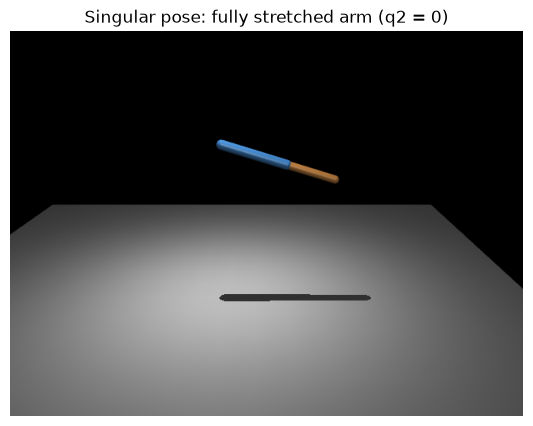

In [10]:
# Render the stretched (singular) pose
mujoco.mj_resetData(model, data)
data.qpos[:] = [0.3, 0.0]
mujoco.mj_forward(model, data)
renderer.update_scene(data, dms.mujoco.make_camera(model))
frame = renderer.render()
plt.figure(figsize=(8, 5))
plt.imshow(frame); plt.axis('off')
plt.title('Singular pose: fully stretched arm (q2 = 0)')
plt.show()

## Section 6: Inverse Kinematics -- Closed Form

**Inverse kinematics (IK)** answers the reverse question: *given a desired
end-effector position, what joint angles reach it?*

For a 2-link arm we can solve it analytically using the law of cosines.
Given target $(x, z)$, define $r_x = x$ and $r_z = z - z_0$ (relative to
the shoulder):

$$
\cos q_2 = \frac{r_x^2 + r_z^2 - L_1^2 - L_2^2}{2 L_1 L_2}
$$

- If $|\cos q_2| > 1$ the target is **outside the workspace** -- no
  solution exists.
- Otherwise there are **two solutions** ($\pm q_2$): *elbow-up* and
  *elbow-down*. Both place the hand at the same point but with the elbow
  on opposite sides.

Then $q_1$ follows from the two-link triangle:

Because $z$ decreases with positive rotation, the shoulder angle uses $-r_z$:

$$q_1 = \mathrm{atan2}(-r_z, r_x) - \mathrm{atan2}\!\left(L_2 \sin q_2,\; L_1 + L_2 \cos q_2\right)$$

In [11]:
def ik_analytic(x, z, elbow='up'):
    """Closed-form IK for the planar RR arm.

    Args:
        x, z: desired end-effector position (world frame).
        elbow: 'up' or 'down' -- selects between the two solutions.

    Returns:
        (q1, q2) in radians, or None if the target is unreachable.
    """
    rx, rz = x, z - Z0
    c2 = (rx**2 + rz**2 - L1**2 - L2**2) / (2 * L1 * L2)
    if abs(c2) > 1:
        return None                      # unreachable
    s2 = np.sqrt(max(0.0, 1 - c2**2))
    if elbow == 'down':
        s2 = -s2
    q2 = np.arctan2(s2, c2)
    q1 = np.arctan2(-rz, rx) - np.arctan2(L2 * s2, L1 + L2 * c2)
    return np.array([q1, q2])

# Both branches must reproduce the same end-effector position
target = (0.5, 0.8)
for elbow in ('up', 'down'):
    q = ik_analytic(*target, elbow=elbow)
    err = np.linalg.norm(fk_analytic(*q) - target)
    print(f"elbow-{elbow:4s}: q = {np.round(q, 4)}, fk error = {err:.2e} m")

elbow-up  : q = [-0.201   1.4033], fk error = 0.00e+00 m
elbow-down: q = [ 0.962  -1.4033], fk error = 5.55e-17 m


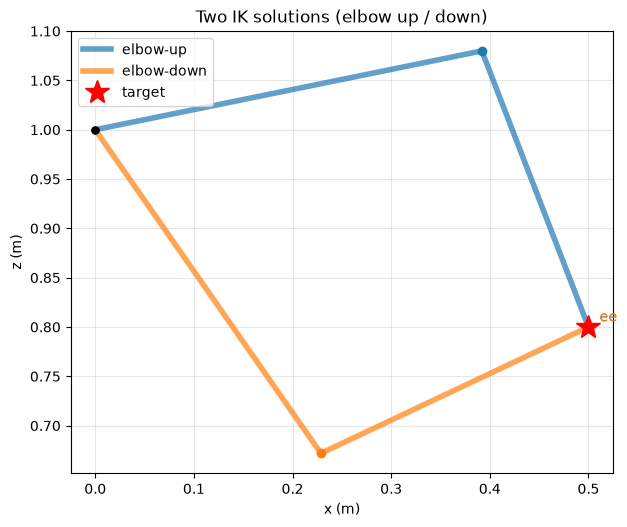

In [12]:
# Visualize the two elbow configurations for the same target
target = (0.5, 0.8)
fig, ax = plt.subplots(figsize=(7, 7))
for elbow, c in [('up', 'C0'), ('down', 'C1')]:
    q = ik_analytic(*target, elbow=elbow)
    plot_arm(ax, *q, color=c, label=f'elbow-{elbow}')
ax.plot(*target, 'r*', markersize=18, label='target')
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.set_xlabel('x (m)'); ax.set_ylabel('z (m)')
ax.legend(); ax.set_title('Two IK solutions (elbow up / down)'); plt.show()

In [13]:
# What happens for unreachable targets?
ik_analytic(2.0, 1.0)   # returns None: beyond the reach L1 + L2 = 0.7 m

## Section 7: Using IK with MuJoCo

MuJoCo itself has no built-in IK solver -- it is a *forward* dynamics
engine. The standard workflow is:

1. Solve IK with your own (or a third-party) solver
2. Set `data.qpos` to the solution
3. Let MuJoCo verify: `mj_forward` + check `site_xpos` against the target

In [14]:
def set_and_verify(q, target):
    """Apply joint angles in MuJoCo and report the achieved ee position."""
    mujoco.mj_resetData(model, data)
    data.qpos[:] = q
    mujoco.mj_forward(model, data)
    achieved = data.site_xpos[ee_id].copy()
    err = np.linalg.norm(achieved[[0, 2]] - target)
    return achieved, err

q = ik_analytic(0.5, 0.8, elbow='up')
achieved, err = set_and_verify(q, (0.5, 0.8))
print(f"target  : (0.5, 0.8)")
print(f"achieved: ({achieved[0]:.6f}, {achieved[2]:.6f})  error = {err:.2e} m")

target  : (0.5, 0.8)
achieved: (0.500000, 0.800000)  error = 1.11e-16 m


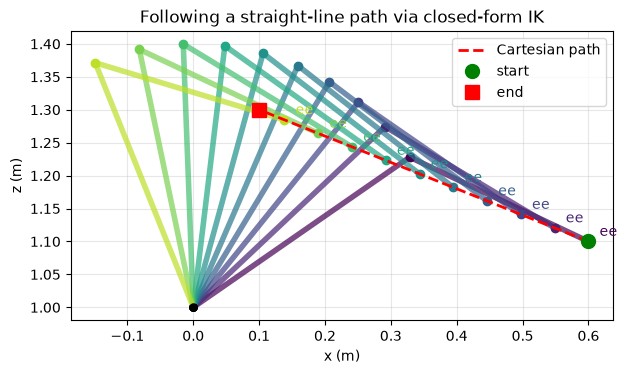

In [15]:
# Trace a straight-line Cartesian path with IK and animate it
targets = np.linspace([0.6, 1.1], [0.1, 1.3], 40)
elbow_solutions = [ik_analytic(x, z, elbow='up') for x, z in targets]

fig, ax = plt.subplots(figsize=(7, 7))
for i, (x, z) in enumerate(targets[::4]):
    q = elbow_solutions[i * 4]
    plot_arm(ax, *q, color=plt.cm.viridis(i / len(targets[::4])))
ax.plot(targets[:, 0], targets[:, 1], 'r--', linewidth=2, label='Cartesian path')
ax.plot(*targets[0], 'go', markersize=10, label='start')
ax.plot(*targets[-1], 'rs', markersize=10, label='end')
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.set_xlabel('x (m)'); ax.set_ylabel('z (m)')
ax.legend(); ax.set_title('Following a straight-line path via closed-form IK')
plt.show()

In [16]:
# Animate the same motion in MuJoCo and save a video
frames = []
renderer = mujoco.Renderer(model, height=480, width=640)
framerate = 30
cam = dms.mujoco.make_camera(model)
for i, (x, z) in enumerate(targets):
    mujoco.mj_resetData(model, data)
    data.qpos[:] = elbow_solutions[i]
    mujoco.mj_forward(model, data)
    if len(frames) <= i * 2:
        renderer.update_scene(data, camera=cam)
        frames.append(renderer.render().copy())
        frames.append(renderer.render().copy())  # hold each pose 2 frames
renderer.close()
media.show_video(frames, fps=framerate)

## Section 8: Numerical IK -- Damped Least Squares

For arms with more joints (or when you want to constrain orientation too),
closed-form IK is usually unavailable. The generic approach is iterative:

**Newton's method**: linearize FK around the current guess,
$e = x_{target} - x(q) \approx J(q)\,\Delta q$, and step
$\Delta q = J^{-1} e$. Repeat until the error is tiny.

**Problem**: near singularities $J$ is ill-conditioned and the step
explodes. **Damped least squares (DLS)** (Levenberg-Marquardt) fixes this
by adding a damping term:

$$\Delta q = J^\top (J J^\top + \lambda^2 I)^{-1} e$$

- $\lambda \to 0$: pure Newton (fast, but unstable near singularities)
- larger $\lambda$: shorter, safer steps

In [17]:
def ik_dls(target, q_init, iters=100, lam=0.05, tol=1e-10):
    """Numerical IK via damped least squares.

    Args:
        target: desired (x, z) end-effector position.
        q_init: initial joint angle guess (also selects the branch).
        iters:  max iterations.
        lam:    damping factor.
        tol:    stop when the 2-norm error is below this.

    Returns:
        (q, iterations, error_history)
    """
    q = np.array(q_init, float)
    target = np.array(target, float)
    history = []
    for i in range(iters):
        e = target - fk_analytic(*q)
        history.append(np.linalg.norm(e))
        if np.linalg.norm(e) < tol:
            break
        J = jac_analytic(*q)
        dq = J.T @ np.linalg.solve(J @ J.T + lam**2 * np.eye(2), e)
        q = q + dq
    return q, i, history

# Same target, different initial guesses -> different branches
target = (0.5, 0.8)
q_up, n_up, hist_up = ik_dls(target, q_init=[0.3, 0.3])
q_dn, n_dn, hist_dn = ik_dls(target, q_init=[0.9, -0.9])
print(f"from q0=[0.3, 0.3] : q = {np.round(q_up, 4)} after {n_up} iters (elbow-up)")
print(f"from q0=[0.9,-0.9] : q = {np.round(q_dn, 4)} after {n_dn} iters (elbow-down)")
print(f"closed form 'up'   : {np.round(ik_analytic(*target, 'up'), 4)}")
print(f"closed form 'down' : {np.round(ik_analytic(*target, 'down'), 4)}")

from q0=[0.3, 0.3] : q = [-0.201   1.4033] after 9 iters (elbow-up)
from q0=[0.9,-0.9] : q = [ 0.962  -1.4033] after 8 iters (elbow-down)
closed form 'up'   : [-0.201   1.4033]
closed form 'down' : [ 0.962  -1.4033]


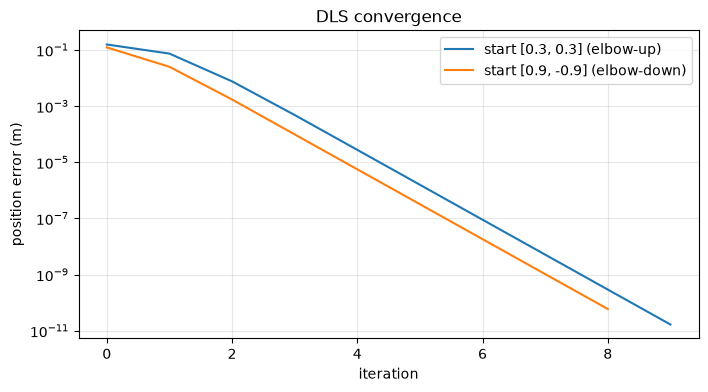

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(hist_up, label=f'start [0.3, 0.3] (elbow-up)')
ax.semilogy(hist_dn, label=f'start [0.9, -0.9] (elbow-down)')
ax.set_xlabel('iteration'); ax.set_ylabel('position error (m)')
ax.set_title('DLS convergence'); ax.grid(True, which='both', alpha=0.3)
ax.legend(); plt.show()

In [19]:
# DLS gracefully handles near-singular targets where Newton would explode
target = (0.699, 1.0)   # 1 mm inside the workspace boundary (nearly singular)
for lam in [0.0, 0.05, 0.3]:
    try:
        q, n, hist = ik_dls(target, q_init=[0.0, 0.0], iters=200, lam=lam)
        print(f"lam={lam:4.2f}: converged in {n:3d} iters, "
              f"final error = {hist[-1]:.2e} m")
    except np.linalg.LinAlgError:
        print(f"lam={lam:4.2f}: Newton step blew up (singular J J^T)")

lam=0.00: Newton step blew up (singular J J^T)
lam=0.05: converged in 199 iters, final error = 1.00e-03 m
lam=0.30: converged in 199 iters, final error = 1.00e-03 m


In [20]:
# Verify a DLS solution inside MuJoCo
q, n, _ = ik_dls((0.45, 1.15), q_init=[0.0, 0.0])
achieved, err = set_and_verify(q, (0.45, 1.15))
print(f"DLS q = {np.round(q, 4)}")
print(f"MuJoCo ee = ({achieved[0]:.6f}, {achieved[2]:.6f}), error = {err:.2e} m")

DLS q = [ 0.3585 -1.6752]
MuJoCo ee = (0.450000, 1.150000), error = 9.44e-12 m


## Summary

| Concept | API / Formula |
|---|---|
| Analytic FK (RR) | $x = L_1 c_1 + L_2 c_{12}$, $z = z_0 - L_1 s_1 - L_2 s_{12}$ |
| FK in MuJoCo | `mujoco.mj_forward(model, data)` then `data.site_xpos[id]` |
| End-effector site | `model.site("ee").id`, `data.site_xpos[id]` |
| Jacobian (MuJoCo) | `mujoco.mj_jacSite(model, data, jacp, jacr, site_id)` |
| Jacobian (analytic) | columns = $\partial$FK$/\partial q_j$ |
| Velocity mapping | $v = J(q)\,\dot q$ |
| Singularity | $\det J = L_1 L_2 \sin q_2 = 0$ (stretched/folded arm) |
| Closed-form IK | law of cosines for $q_2$, `atan2` for $q_1$ |
| Numerical IK | $\Delta q = J^\top (J J^\top + \lambda^2 I)^{-1} (x^* - x(q))$ |
| Two IK branches | elbow-up / elbow-down ($\pm q_2$) |

## Key Takeaways

- **FK is easy and unique**: evaluate the kinematic chain (or let MuJoCo do
  it with `mj_forward`).
- **IK is hard and non-unique**: multiple solutions (elbow up/down),
  no solution outside the workspace, and degenerate behavior near
  singularities.
- The **Jacobian** is the bridge between joint space and Cartesian space:
  velocities, singularity analysis, and numerical IK all rely on it.
- MuJoCo gives you FK and Jacobians for free for *any* model -- no matter
  how complex -- so closed-form solutions are only needed when you need
  IK speed or analytic insight.